# Create classification RNN model with LSTM layer

In [20]:
import torch
import torch.optim as optim
import torch.utils.data as data
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

from collections import Counter
import string
from tqdm.auto import tqdm
from nltk.tokenize import word_tokenize
import nltk
import pickle
sns.set_palette('summer')

In [21]:
import sympy
sympy.__version__

'1.14.0'

In [22]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [23]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/course/datasets/data_coindesk_base.csv')
df = df[['ID', 'PUBLISHED_ON', 'BODY', 'SENTIMENT']]
df['PUBLISHED_ON'] = pd.to_datetime(df['PUBLISHED_ON'], unit='s')
df = df.dropna()
df.loc[df['SENTIMENT'] == 'POSITIVE', 'SENTIMENT'] = 1
df.loc[df['SENTIMENT'] == 'NEGATIVE', 'SENTIMENT'] = 2
df.loc[df['SENTIMENT'] == 'NEUTRAL', 'SENTIMENT'] = 0
df.sample(2)

,ID,PUBLISHED_ON,BODY,SENTIMENT
133536,31376810,2024-07-22 15:01:00,Bitcoin founding words by Satoshi reverberate ...,1
174466,21772834,2023-12-26 07:21:17,"In a remarkable surge, Bitcoin has reached $43...",1


In [26]:
len(df)

182099

# Text proceccing

## Vocabulary

In [27]:
vocab = set(['<unk>', '<bos>', '<eos>', '<pad>'])
dct = Counter()

for art in tqdm(df['BODY']):
  proc = art.lower().translate(str.maketrans('', '', string.punctuation))

  for word in word_tokenize(proc):
    dct[word] += 1

  0%|          | 0/182099 [00:00<?, ?it/s]

In [28]:
threshold = 20
vocab = set(['<unk>', '<bos>', '<eos>', '<pad>'])

for key, val in dct.items():
  if val > threshold:
    vocab.add(key)

len(vocab)

30024

## Word2ind and ind2word

In [29]:
w2i = {w: i for i, w in enumerate(vocab)}
i2w = {i: w for w, i in w2i.items()}

w2i['ahlgren'], i2w[0]

(18444, '4180')

## WordDataset

In [30]:
class WordDataset:
  def __init__(self, dataset, target, word2ind=w2i, ind2word=i2w):
    self.dataset = dataset
    self.target = target
    self.word2ind = word2ind
    self.ind2word = ind2word
    self.bos_id = self.word2ind['<bos>']
    self.eos_id = self.word2ind['<eos>']
    self.pad_id = self.word2ind['<pad>']
    self.unk_id = self.word2ind['<unk>']

  def __getitem__(self, indx):
    '''
    takes index
    returns article from dataset with that index
    in article are indecies insted of words
    '''
    art2ind = [self.pad_id]
    proc_art = self.dataset[indx].lower().translate(str.maketrans('', '', string.punctuation))

    for t in word_tokenize(proc_art):
      art2ind.append(self.word2ind.get(t, self.unk_id))

    art2ind.append(self.eos_id)

    result = {
        'art2ind': art2ind,
        'target': self.target[indx]
    }
    return result

  def __len__(self):
    return len(self.dataset)

## Collate function

- collate batch with padding

1576.4550711426202 71179


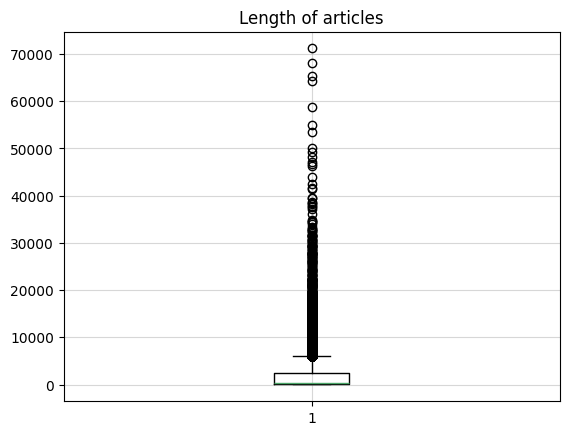

In [31]:
print(np.mean([len(x) for x in df['BODY']]), max([len(x) for x in df['BODY']]))
lns = [len(df['BODY'].values[i]) for i in range(len(df['BODY']))]
plt.boxplot(lns)
plt.grid(True, alpha=0.5)
plt.title('Length of articles')
plt.show()

In [32]:
def collate_with_padding(batch, pad_id=w2i['<pad>'], dev=device, max_len=256):
  '''
  formats batch so that sequences are the same length, using padding
  '''
  targets = [x['target'] for x in batch]

  lns = [len(x['art2ind']) for x in batch]
  mx = min(max_len, max(lns))

  arts = []
  for x in batch:
    art = x['art2ind'][:mx]
    # add padding
    for i in range(mx - len(art)):
      art.append(pad_id)

    arts.append(art)

  # convert to tensors
  arts = torch.tensor(arts, dtype=torch.int64).to(dev)
  targets = torch.tensor(targets, dtype=torch.int64).to(dev)

  # batch
  result = {
      'art2ind_pad': arts,
      'targets': targets
  }
  return result

In [33]:
df = df.sample(frac=1, random_state=52)
df.dropna(inplace=True)
X = df['BODY']
y = df['SENTIMENT']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.25)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5)

## Dataloaders

In [34]:
# To reset indecies for dataloader,
# which start with index 1, which may be in the train/test/val dataset
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_val   = X_val.reset_index(drop=True)
y_val   = y_val.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

In [35]:
train_dataset = WordDataset(X_train, y_train, w2i, i2w)
val_dataset = WordDataset(X_val, y_val, w2i, i2w)
test_dataset = WordDataset(X_test, y_test, w2i, i2w)

batch_size = 128

train_dataloader = data.DataLoader(train_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_with_padding)
val_dataloader = data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_with_padding)
test_dataloader = data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_with_padding)

# Model

In [36]:
class LSTM_classifier(nn.Module):
  def __init__(self, vocab_size, hidden_size,
               num_hidden_linear=2, num_hidden_lstm=1, bidir=False,
               num_classes=3, agg_type='max'):
    super().__init__()
    self.agg_type = agg_type
    self.bidir = bidir

    self.b = 1
    if self.bidir:
      self.b = 2

    self.num_classes = num_classes
    self.num_hidden_linear = num_hidden_linear
    self.num_hidden_lstm = num_hidden_lstm
    self.embeddings = nn.Embedding(vocab_size, hidden_size)

    if self.num_hidden_lstm == 1:
      self.lstm = nn.LSTM(hidden_size, hidden_size, batch_first=True,
                          num_layers=self.num_hidden_lstm,
                          bidirectional=self.bidir)
    elif self.num_hidden_lstm > 1:
      self.lstm = nn.LSTM(hidden_size, hidden_size, batch_first=True,
                          num_layers=self.num_hidden_lstm, dropout=0.1,
                          bidirectional=self.bidir)
    else:
      raise ValueError(f'Incorrect value of lstm layers: {self.num_hidden_lstm}')

    self.linear = nn.Linear(hidden_size * self.b, hidden_size * self.b)
    self.output_linear = nn.Linear(hidden_size * self.b, 3)
    self.dropout = nn.Dropout(p=0.1)
    self.act = nn.Tanh()


  def forward(self, batch):
    emb = self.embeddings(batch)
    output, (h, c) = self.lstm(emb)

    if self.agg_type == 'max':
      res = output.max(dim=1)[0]
    elif self.agg_type == 'mean':
      res = output.mean(dim=1)
    elif self.agg_type == 'last':
      if not self.bidir:
        res = h[-1]
      else:
        # concatenate last of hidden vectors on last lstm layer
        res = torch.cat([h[-2], h[-1]], dim=1)

    else:
      raise ValueError(f'Incorrect agg type: {self.agg_type}')

    for i in range(self.num_hidden_linear):
      if i < self.num_hidden_linear - 1:
        res = self.linear(res)
        res = self.act(res)
        res = self.dropout(res)
      else:
        res = self.output_linear(res)

    return res

## Evaluate func

In [37]:
def evaluate(model, dataloader):
  '''
  args:
    model for evaluate
    dataloader for evaluate a model
  '''
  predictions = []
  targets = []
  losses = []
  lf = nn.CrossEntropyLoss()

  model.eval()
  with torch.no_grad():
    for batch in dataloader:
      predict = model(batch['art2ind_pad'])
      l = lf(predict, batch['targets'])

      losses.append(l.item())
      predictions.append(predict.argmax(dim=1))
      targets.append(batch['targets'])

  model.train()

  predictions = torch.cat(predictions)
  targets = torch.cat(targets)
  loss_mean = sum(losses) / len(losses)
  acc = (predictions == targets).float().mean().item()
  return acc, loss_mean

# Train loop with early stopping

In [38]:
epochs = 30

types = {}

for num_linear in [2, 3]:
  print(f'Start learning for {num_linear} linear layers')
  key = 'two_linear' if num_linear == 2 else 'three_linear'

  curr_losses_train = []
  curr_losses_val = []
  curr_acc = []

  model = LSTM_classifier(
      vocab_size=len(vocab),
      hidden_size=256,
      num_hidden_linear=num_linear,
      num_hidden_lstm=1,
      bidir=False,
      num_classes=3,
      agg_type='mean'
  ).to(device)
  optimizer = optim.Adam(params=model.parameters(), lr=0.001)
  loss_func = nn.CrossEntropyLoss()

  best_val_loss = float('inf')
  patience = 0
  for e in range(epochs):
    epoch_loss_train = []

    for i, batch in enumerate(tqdm(train_dataloader, desc=f'Epoch {e+1}/{epochs}')):
      optimizer.zero_grad()

      predict = model(batch['art2ind_pad'])
      loss = loss_func(predict, batch['targets'])
      epoch_loss_train.append(loss.item())

      loss.backward()
      optimizer.step()

    # evaluate after epoch
    a, lm = evaluate(model, val_dataloader)
    curr_losses_val.append(lm)
    curr_acc.append(a)
    curr_losses_train.append(np.mean(epoch_loss_train))

    # logs
    types[key] = {
        'train_losses': curr_losses_train,
        'val_losses': curr_losses_val,
        'accuracy': curr_acc
    }

    with open(f'logs_dict.pkl', 'wb') as f:
      pickle.dump(types, f)

    print(f'Loss mean train/validation: {np.mean(epoch_loss_train)}/{lm}, Accuracy: {a}')

    if best_val_loss >= lm:
      # save
      st = model.state_dict()
      torch.save(st, f'LSTMclassifier_256_{num_linear}_1_uni_mean.tar')
      # update
      best_val_loss = lm
      patience = 0

    else:
      patience += 1

    if patience > 2:
      break

Start learning for 2 linear layers


Epoch 1/30:   0%|          | 0/1067 [00:00<?, ?it/s]

Loss mean train/validation: 0.6901035296827582/0.5688657891214564, Accuracy: 0.7569740414619446


Epoch 2/30:   0%|          | 0/1067 [00:00<?, ?it/s]

Loss mean train/validation: 0.503468462486857/0.5351201684287424, Accuracy: 0.7730527520179749


Epoch 3/30:   0%|          | 0/1067 [00:00<?, ?it/s]

Loss mean train/validation: 0.4046424877705033/0.5795018595925877, Accuracy: 0.7723498940467834


Epoch 4/30:   0%|          | 0/1067 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
epochs = 30

types_1 = {}

for num_linear in [2, 3]:
  print(f'Start learning for {num_linear} linear layers')
  key = 'two_linear' if num_linear == 2 else 'three_linear'

  curr_losses_train = []
  curr_losses_val = []
  curr_acc = []

  model = LSTM_classifier(
      vocab_size=len(vocab),
      hidden_size=300,
      num_hidden_linear=num_linear,
      num_hidden_lstm=1,
      bidir=True,
      num_classes=3,
      agg_type='last'
  ).to(device)
  optimizer = optim.Adam(params=model.parameters(), lr=0.001)
  loss_func = nn.CrossEntropyLoss()

  best_val_loss = float('inf')
  patience = 0
  for e in range(epochs):
    epoch_loss_train = []

    for i, batch in enumerate(tqdm(train_dataloader, desc=f'Epoch {e+1}/{epochs}')):
      optimizer.zero_grad()

      predict = model(batch['art2ind_pad'])
      loss = loss_func(predict, batch['targets'])
      epoch_loss_train.append(loss.item())

      loss.backward()
      optimizer.step()

    # evaluate after epoch
    a, lm = evaluate(model, val_dataloader)
    curr_losses_val.append(lm)
    curr_acc.append(a)
    curr_losses_train.append(np.mean(epoch_loss_train))

    # logs
    types_1[key] = {
        'train_losses': curr_losses_train,
        'val_losses': curr_losses_val,
        'accuracy': curr_acc
    }

    with open(f'logs_dict_1.pkl', 'wb') as f:
      pickle.dump(types_1, f)

    print(f'Loss mean train/validation: {np.mean(epoch_loss_train)}/{lm}, Accuracy: {a}')

    if best_val_loss >= lm:
      # save
      st = model.state_dict()
      torch.save(st, f'LSTMclassifier_300_{num_linear}_1_bi_last.tar')
      # update
      best_val_loss = lm
      patience = 0

    else:
      patience += 1

    if patience > 2:
      break